# Duration Stance — Horizon-Set Prototype

Minimal prototype for the current Duration market branch.

Current working assumptions:

- Raw Observation: FRED `DGS10`
- Features: moving-average differences
- General horizon structure: `R_fast < R_slow <= T_fast < T_slow`
- Component States: `falling / stable / rising`
- Core Stance: canonical 3 × 3 Duration Stance Rule Table


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

FRED_CSV = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10"

# DGS10 is expressed in percentage points, so 0.10 = 10 bp.
STABLE_BAND = 0.10

RULE_MAP = {
    ("falling", "falling"): +3,
    ("falling", "stable"):  +2,
    ("falling", "rising"):  +1,
    ("stable",  "falling"): +1,
    ("stable",  "stable"):   0,
    ("stable",  "rising"):  -1,
    ("rising",  "falling"): -1,
    ("rising",  "stable"):  -2,
    ("rising",  "rising"):  -3,
}


## 2. Download FRED 10-Year Treasury Yield

In [2]:
raw = pd.read_csv(FRED_CSV, na_values=".")

date_col = raw.columns[0]
raw[date_col] = pd.to_datetime(raw[date_col])
raw["DGS10"] = pd.to_numeric(raw["DGS10"], errors="coerce")

dgs10 = (
    raw[[date_col, "DGS10"]]
    .dropna()
    .set_index(date_col)["DGS10"]
    .sort_index()
)

dgs10.tail()


observation_date
2026-09-03    4.77
2026-09-04    4.78
2026-09-08    4.80
2026-09-09    4.83
2026-09-10    4.95
Name: DGS10, dtype: float64

<Axes: xlabel='observation_date'>

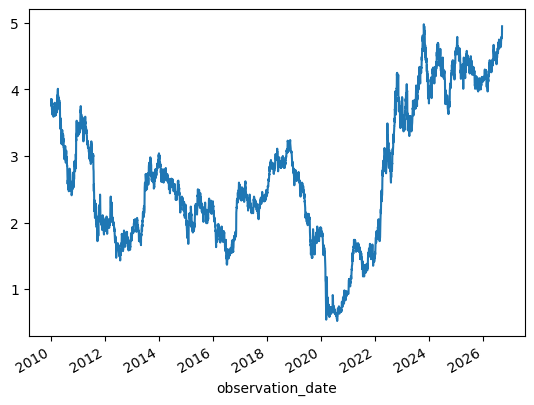

In [11]:
dgs10.loc['2010':].plot()

## 3. Define Candidate Horizon Sets

In [12]:
# Windows are trading-observation counts, approximately:
# 21 ~= 1 month, 42 ~= 2 months, 63 ~= 3 months,
# 126 ~= 6 months, 252 ~= 12 months.

HORIZON_SETS = {
    "shared_mid_1_3_12": {
        "r_fast": 21,
        "r_slow": 63,
        "t_fast": 63,
        "t_slow": 252,
    },
    "four_ma_1_3_6_12": {
        "r_fast": 21,
        "r_slow": 63,
        "t_fast": 126,
        "t_slow": 252,
    },
    "four_ma_1_2_6_12": {
        "r_fast": 21,
        "r_slow": 42,
        "t_fast": 126,
        "t_slow": 252,
    },
    "four_ma_2_3_6_12": {
        "r_fast": 42,
        "r_slow": 63,
        "t_fast": 126,
        "t_slow": 252,
    },
}

pd.DataFrame(HORIZON_SETS).T


,r_fast,r_slow,t_fast,t_slow
shared_mid_1_3_12,21,63,63,252
four_ma_1_3_6_12,21,63,126,252
four_ma_1_2_6_12,21,42,126,252
four_ma_2_3_6_12,42,63,126,252


## 4. Calculate MA Features and Component States

In [13]:
def classify_state(feature: pd.Series, stable_band: float = STABLE_BAND) -> pd.Series:
    state = pd.Series(pd.NA, index=feature.index, dtype="object")
    state[feature < -stable_band] = "falling"
    state[feature.abs() <= stable_band] = "stable"
    state[feature > stable_band] = "rising"
    return state


def calculate_features(
    yield_series: pd.Series,
    horizons: dict,
    stable_band: float = STABLE_BAND,
) -> pd.DataFrame:
    r_fast = yield_series.rolling(horizons["r_fast"]).mean()
    r_slow = yield_series.rolling(horizons["r_slow"]).mean()
    t_fast = yield_series.rolling(horizons["t_fast"]).mean()
    t_slow = yield_series.rolling(horizons["t_slow"]).mean()

    out = pd.DataFrame(index=yield_series.index)
    out["yield"] = yield_series

    out["recent_feature"] = r_fast - r_slow
    out["trend_feature"] = t_fast - t_slow

    out["recent_state"] = classify_state(out["recent_feature"], stable_band)
    out["trend_state"] = classify_state(out["trend_feature"], stable_band)

    return out


## 5. Map Rule Cases to Core Stance

In [14]:
def apply_rule_map(features: pd.DataFrame) -> pd.DataFrame:
    out = features.copy()

    out["core_stance"] = [
        RULE_MAP.get((trend, recent), np.nan)
        for trend, recent in zip(out["trend_state"], out["recent_state"])
    ]

    valid = out["core_stance"].notna()
    out.loc[valid, "rule_case"] = (
        out.loc[valid, "trend_state"].astype(str)
        + " | "
        + out.loc[valid, "recent_state"].astype(str)
    )

    return out


## 6. Run All Horizon Sets

In [15]:
results = {}

for name, horizons in HORIZON_SETS.items():
    features = calculate_features(dgs10, horizons)
    results[name] = apply_rule_map(features).dropna(subset=["core_stance"])

latest = pd.DataFrame(
    {
        name: df.iloc[-1][
            [
                "yield",
                "trend_feature",
                "trend_state",
                "recent_feature",
                "recent_state",
                "rule_case",
                "core_stance",
            ]
        ]
        for name, df in results.items()
    }
).T

latest


,yield,trend_feature,trend_state,recent_feature,recent_state,rule_case,core_stance
shared_mid_1_3_12,4.95,0.303373,rising,0.11127,rising,rising | rising,-3.0
four_ma_1_3_6_12,4.95,0.191389,rising,0.11127,rising,rising | rising,-3.0
four_ma_1_2_6_12,4.95,0.191389,rising,0.04119,stable,rising | stable,-2.0
four_ma_2_3_6_12,4.95,0.191389,rising,0.070079,stable,rising | stable,-2.0


<Axes: xlabel='observation_date'>

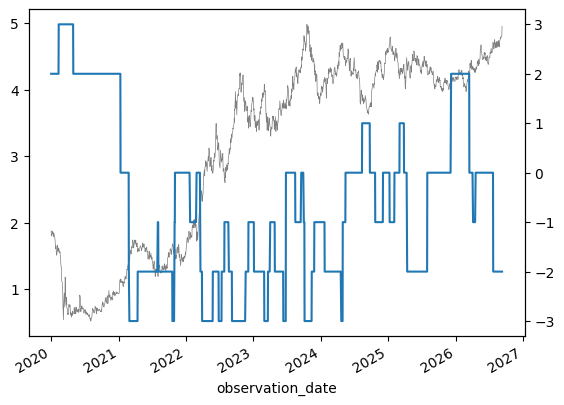

In [35]:
case = 'four_ma_1_2_6_12'
start = '2020'
df = results[case].loc[start:]
ax = df.iloc[:, 0].plot(c='grey', lw=0.5)
#df.iloc[:, 1:3].plot(ax=ax.twinx())
df['core_stance'].plot(ax=ax.twinx())

## 7. Compare Horizon-Set Behavior

In [36]:
def median_run_length(series: pd.Series) -> float:
    run_id = series.ne(series.shift()).cumsum()
    return float(series.groupby(run_id).size().median())


def summarize_result(df: pd.DataFrame) -> pd.Series:
    stance = df["core_stance"]
    transitions = int(stance.ne(stance.shift()).sum() - 1)

    years = (df.index.max() - df.index.min()).days / 365.25
    transitions_per_year = transitions / years if years > 0 else np.nan

    return pd.Series(
        {
            "start": df.index.min(),
            "end": df.index.max(),
            "valid_observations": len(df),
            "stance_transitions": transitions,
            "transitions_per_year": transitions_per_year,
            "median_stance_run_obs": median_run_length(stance),
            "distinct_rule_cases": df["rule_case"].nunique(),
        }
    )


comparison = pd.DataFrame(
    {name: summarize_result(df) for name, df in results.items()}
).T

comparison


,start,end,valid_observations,stance_transitions,transitions_per_year,median_stance_run_obs,distinct_rule_cases
shared_mid_1_3_12,1963-01-04 00:00:00,2026-09-10 00:00:00,15907,590,9.264725,20.0,9
four_ma_1_3_6_12,1963-01-04 00:00:00,2026-09-10 00:00:00,15907,574,9.013478,21.0,9
four_ma_1_2_6_12,1963-01-04 00:00:00,2026-09-10 00:00:00,15907,607,9.531675,19.0,9
four_ma_2_3_6_12,1963-01-04 00:00:00,2026-09-10 00:00:00,15907,425,6.673742,24.0,9


## 8. Compare Rule-Case Occupancy

In [37]:
occupancy_rows = []

for name, df in results.items():
    share = df["rule_case"].value_counts(normalize=True).sort_index()
    row = {"horizon_set": name, **share.to_dict()}
    occupancy_rows.append(row)

rule_case_occupancy = (
    pd.DataFrame(occupancy_rows)
    .set_index("horizon_set")
    .fillna(0.0)
)

rule_case_occupancy


,falling | falling,falling | rising,falling | stable,rising | falling,rising | rising,rising | stable,stable | falling,stable | rising,stable | stable
horizon_set,,,,,,,,,
shared_mid_1_3_12,0.157101,0.067015,0.154335,0.080719,0.172188,0.165399,0.042811,0.043943,0.116490
four_ma_1_3_6_12,0.121330,0.079399,0.144276,0.085308,0.132520,0.141447,0.073993,0.071227,0.150500
four_ma_1_2_6_12,0.071792,0.059848,0.213365,0.060728,0.080845,0.217703,0.045326,0.040925,0.209468
four_ma_2_3_6_12,0.066260,0.040422,0.238323,0.037908,0.072610,0.248758,0.036525,0.027409,0.231785
